## Soham Kharabe
## C_C2_23
## ML Lab - 6
## ANN
## 22/09/2026

In [1]:
%pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable
  Using cached tensorflow-2.21.0-cp313-cp313-win_amd64.whl.metadata (4.5 kB)
Using cached tensorflow-2.21.0-cp313-cp313-win_amd64.whl (351.2 MB)
Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score,
    StratifiedKFold
)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping

In [3]:
df = pd.read_csv("seeds.csv")

In [4]:
df = df.dropna(axis=1, how="all")

In [5]:
df = df.loc[:,~df.columns.str.startswith("Unnamed")]

In [6]:
df.head()

,Area,Perimeter,Compactness,Length of kernel,Width of kernel,Asymmetry coefficient,Length of kernel groove,"Class (1, 2, 3)"
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1


In [7]:
df.tail()

,Area,Perimeter,Compactness,Length of kernel,Width of kernel,Asymmetry coefficient,Length of kernel groove,"Class (1, 2, 3)"
205,12.19,13.20,0.8783,5.137,2.981,3.631,4.870,3
206,11.23,12.88,0.8511,5.140,2.795,4.325,5.003,3
207,13.20,13.66,0.8883,5.236,3.232,8.315,5.056,3
208,11.84,13.21,0.8521,5.175,2.836,3.598,5.044,3
209,12.30,13.34,0.8684,5.243,2.974,5.637,5.063,3


In [8]:
df.shape

(210, 8)

In [9]:
df.columns

Index(['Area', 'Perimeter', 'Compactness', 'Length of kernel',
       'Width of kernel', 'Asymmetry coefficient', 'Length of kernel groove',
       'Class (1, 2, 3)'],
      dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Area                     210 non-null    float64
 1   Perimeter                210 non-null    float64
 2   Compactness              210 non-null    float64
 3   Length of kernel         210 non-null    float64
 4   Width of kernel          210 non-null    float64
 5   Asymmetry coefficient    210 non-null    float64
 6   Length of kernel groove  210 non-null    float64
 7   Class (1, 2, 3)          210 non-null    int64  
dtypes: float64(7), int64(1)
memory usage: 13.3 KB


In [12]:
df.isnull().sum()

Area                       0
Perimeter                  0
Compactness                0
Length of kernel           0
Width of kernel            0
Asymmetry coefficient      0
Length of kernel groove    0
Class (1, 2, 3)            0
dtype: int64

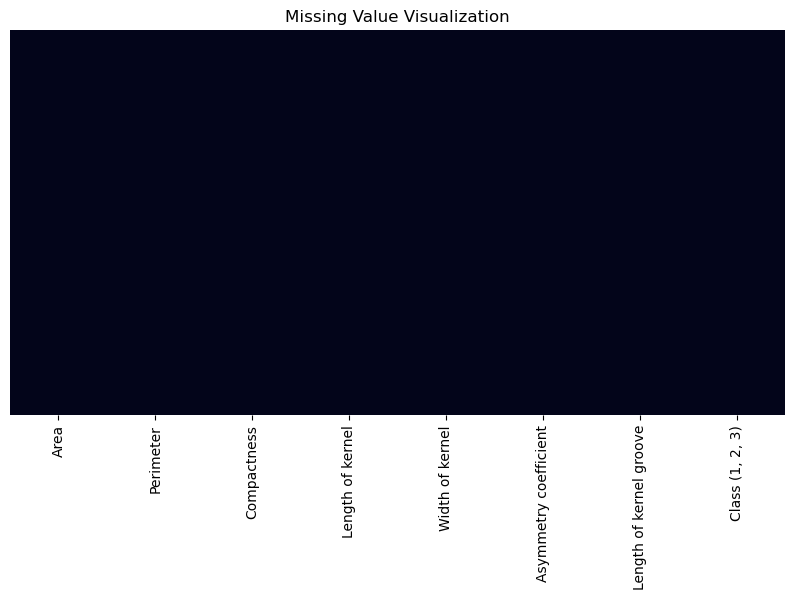

In [13]:
plt.figure(figsize=(10,5))
sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False
)
plt.title("Missing Value Visualization")
plt.show()

In [14]:
duplicate_count = df.duplicated().sum()
print("Number of Duplicated Rows:", duplicate_count)

Number of Duplicated Rows: 0


In [16]:
print(df["Class (1, 2, 3)"].value_counts())

Class (1, 2, 3)
1    70
2    70
3    70
Name: count, dtype: int64


<Axes: xlabel='Class (1, 2, 3)', ylabel='count'>

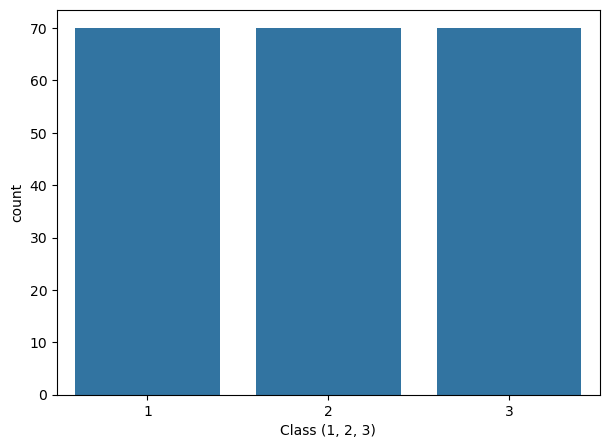

In [17]:
plt.figure(figsize=(7,5))
sns.countplot(
    data=df,
    x="Class (1, 2, 3)"
)

In [18]:
target_percentage = (
    df["Class (1, 2, 3)"]
    .value_counts(normalize=True)
    .sort_index()
    *100
)
print(target_percentage)

Class (1, 2, 3)
1    33.333333
2    33.333333
3    33.333333
Name: proportion, dtype: float64


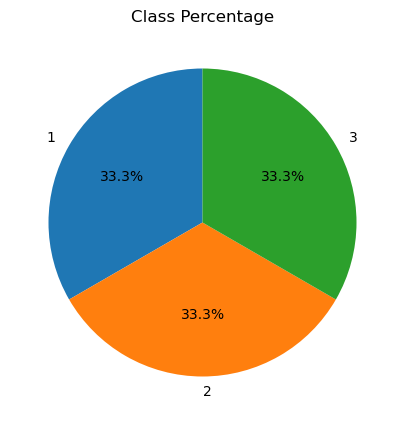

In [25]:
plt.figure(figsize=(7,5))
plt.pie(target_percentage,labels=["1","2","3"],autopct="%1.1f%%",startangle=90)
plt.title("Class Percentage")
plt.show()

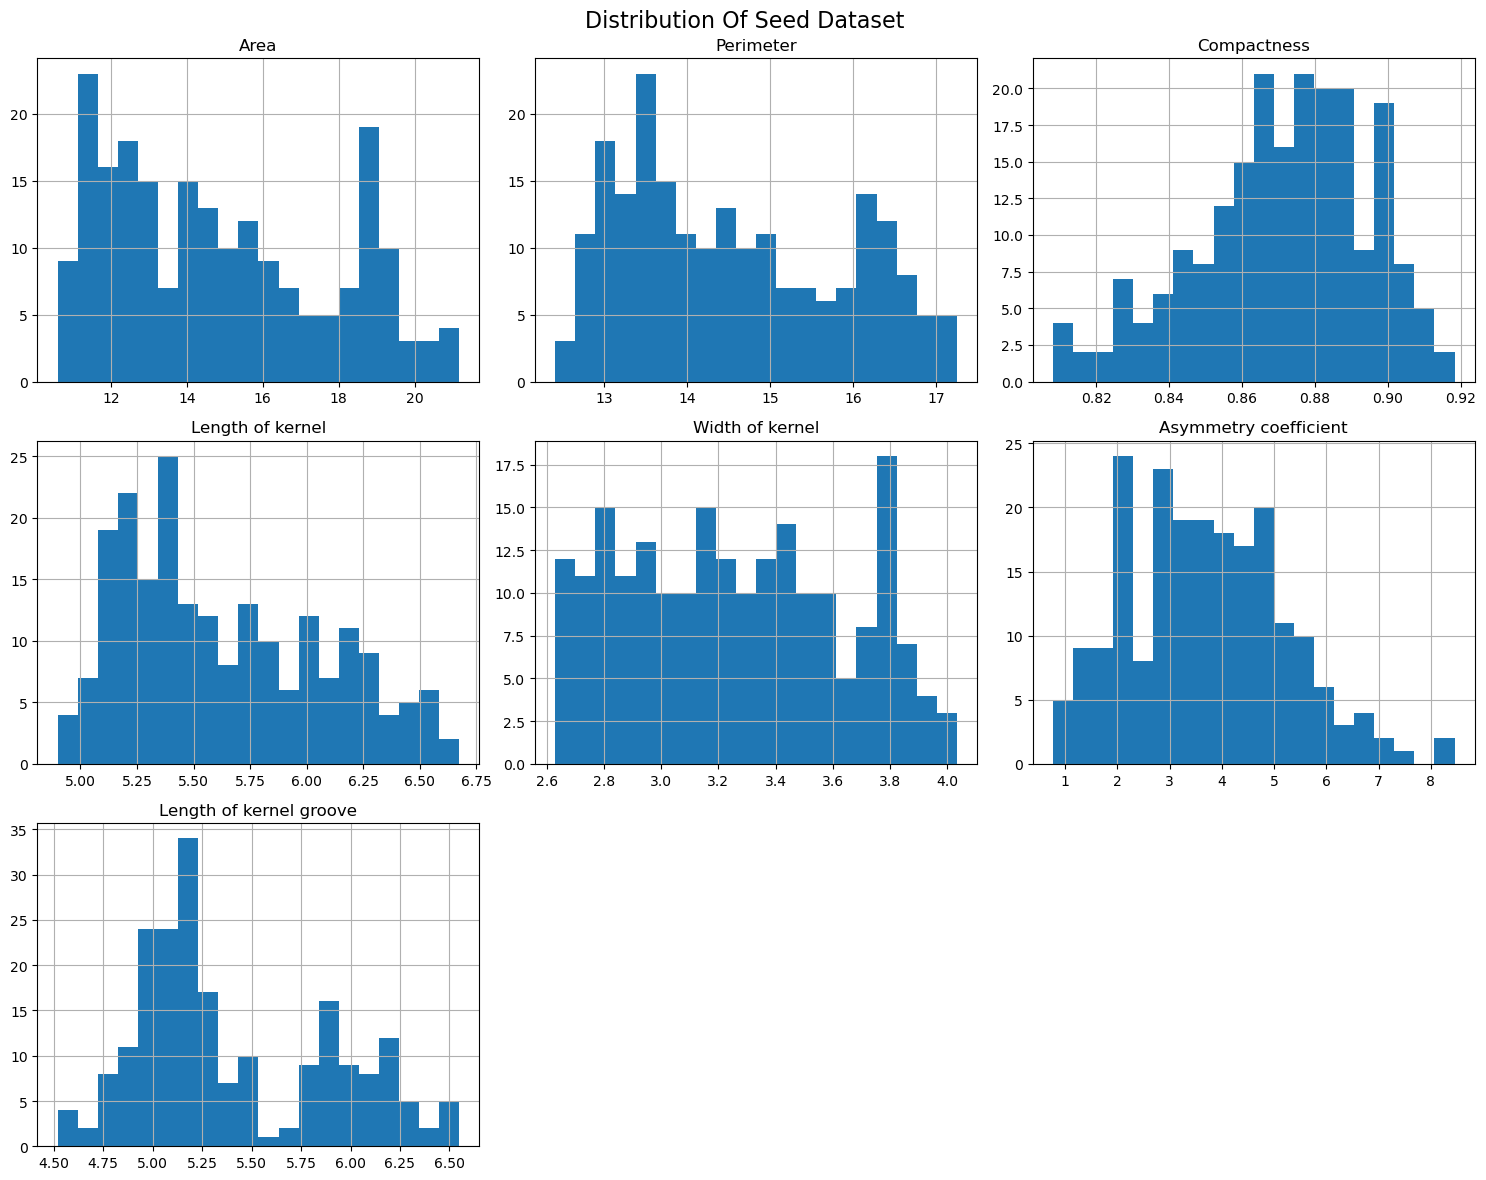

In [26]:
features = df.drop(columns="Class (1, 2, 3)").columns
df[features].hist(figsize=(15,12),bins=20)
plt.suptitle("Distribution Of Seed Dataset",fontsize=16)
plt.tight_layout()
plt.show()

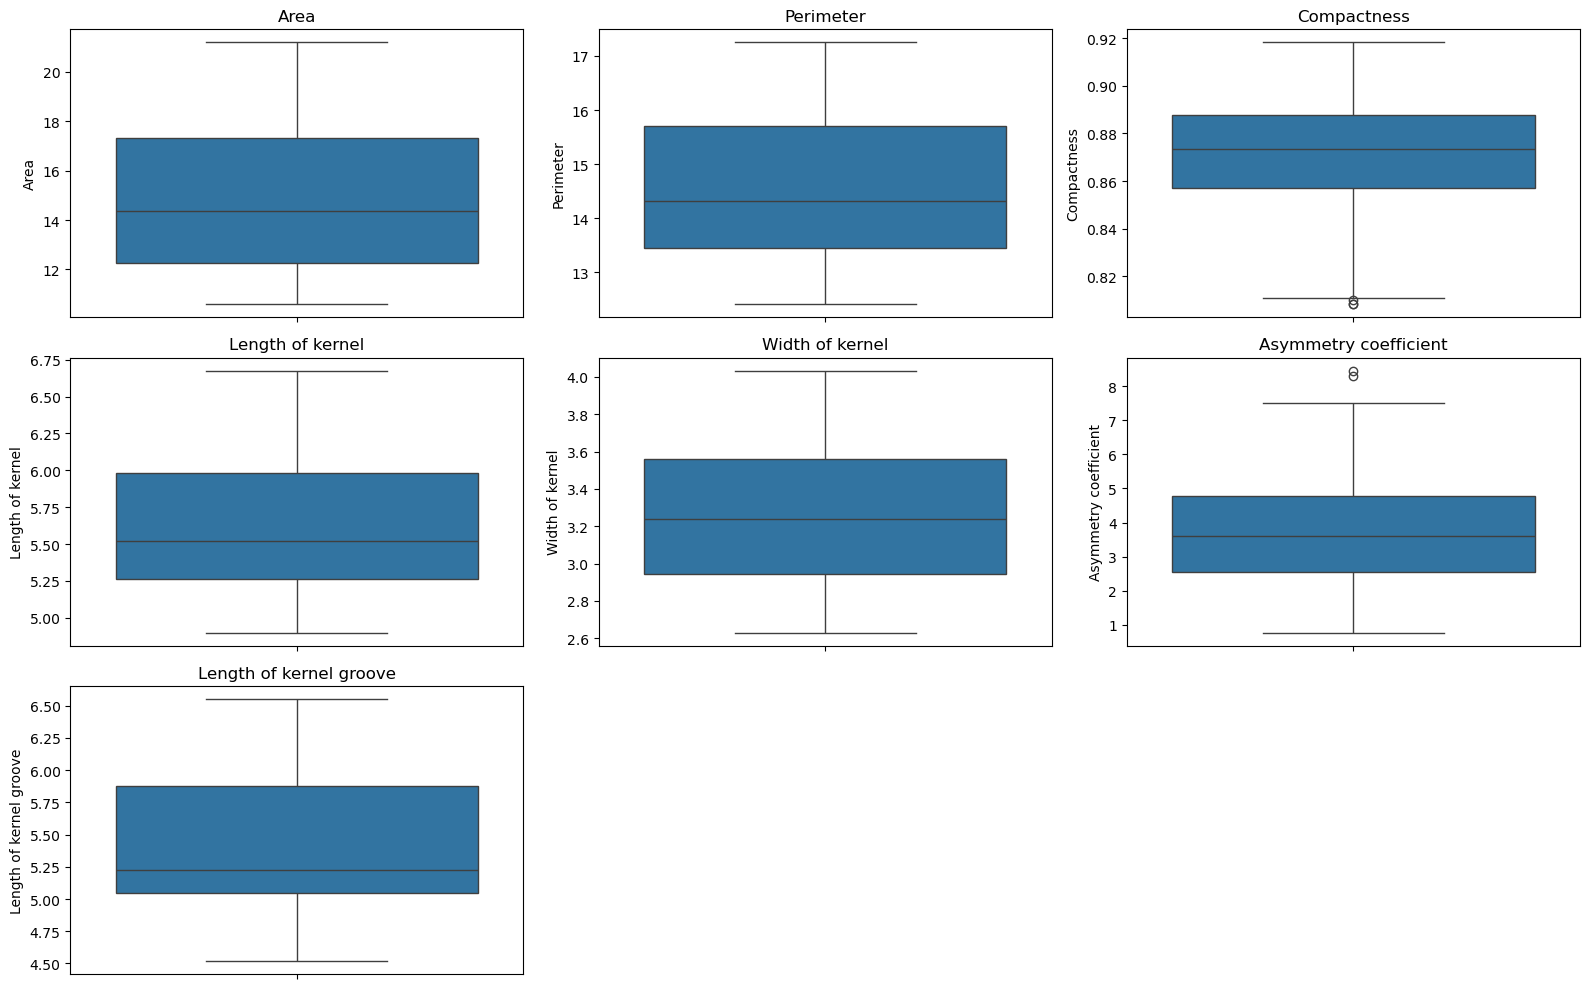

In [28]:
plt.figure(figsize=(16,10))
for i,col in enumerate(features,1):
    plt.subplot(3,3,i)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [29]:
zero_columns = ['Area', 'Perimeter', 'Compactness', 'Length of kernel',
       'Width of kernel', 'Asymmetry coefficient', 'Length of kernel groove']
zero_counts = (df[zero_columns] == 0).sum()
print("Zero Values:")
print(zero_counts)

Zero Values:
Area                       0
Perimeter                  0
Compactness                0
Length of kernel           0
Width of kernel            0
Asymmetry coefficient      0
Length of kernel groove    0
dtype: int64


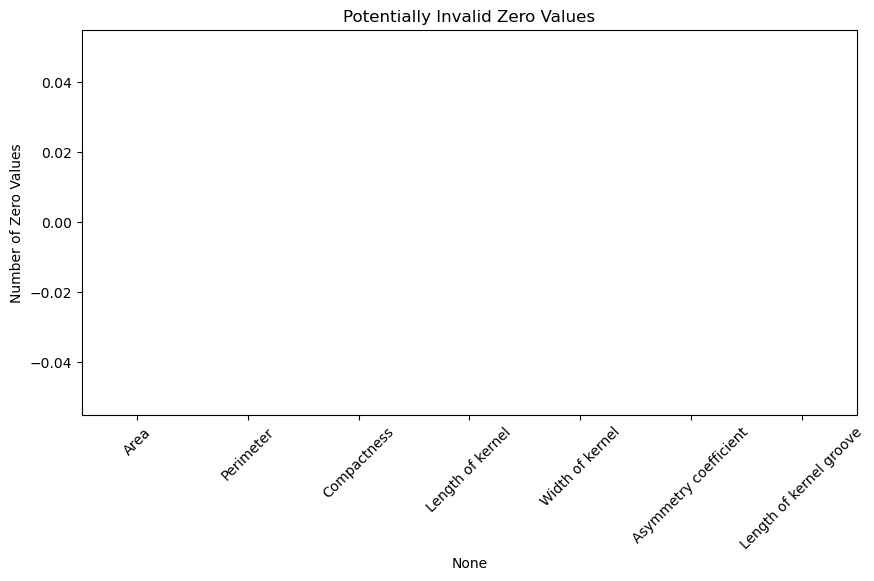

In [30]:
plt.figure(figsize=(10,5))
sns.barplot(x=zero_counts.index,y=zero_counts.values)
plt.xticks(rotation=45)
plt.ylabel("Number of Zero Values")
plt.title("Potentially Invalid Zero Values")
plt.show()

### ANN Algorithm

In [20]:
X = df.drop("Class (1, 2, 3)", axis=1)
y_original = df["Class (1, 2, 3)"]
print("Input shape:",X.shape)
print("Target Shape:",y_original.shape)

Input shape: (210, 7)
Target Shape: (210,)


In [21]:
y = y_original - 1
print("Original Classes:")
print(sorted(y_original.unique()))
print("\nANN encoded classes:")
print(sorted(y.unique()))

Original Classes:
[np.int64(1), np.int64(2), np.int64(3)]

ANN encoded classes:
[np.int64(0), np.int64(1), np.int64(2)]


In [22]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.20,random_state = 42,stratify=y)
print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])

Training Samples: 168
Testing Samples: 42


In [23]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Scaling Completed")

Scaling Completed


In [24]:
scaler.fit_transform(X_test)

array([[-0.13481356, -0.30885661,  1.63834475, -0.72108928,  0.28326462,
        -0.76430253, -1.20943602],
       [-0.86696115, -0.79265998, -1.079508  , -0.44412568, -1.01611436,
        -0.08296069, -0.1493714 ],
       [ 0.3031065 ,  0.49244271, -0.70339658,  0.66153059,  0.00779627,
        -0.80711315,  0.9685525 ],
       [-1.32882996, -1.4578896 , -0.42131302, -1.40250766, -1.05769449,
         0.74059948, -0.71763216],
       [ 1.23710786,  1.05184035,  1.89804073,  0.79121989,  1.36954545,
        -0.66416923,  1.14006393],
       [-0.46667485, -0.42224803, -0.31833013, -0.17155833, -0.40280748,
         2.38191499,  0.06140168],
       [ 2.15058173,  2.0799225 ,  0.78313902,  2.07492419,  1.98285233,
         0.67094153,  1.87157051],
       [ 0.37495276,  0.31101645,  1.0697001 ,  0.12079214,  0.53534414,
         1.33559449, -0.56678476],
       [ 1.65107916,  1.67171341,  0.42941519,  1.6418938 ,  1.48908831,
        -0.57346877,  1.60087175],
       [ 1.28842662,  1.2257

In [27]:
print("First 5 Scaled Training Samples:")
print(X_train_scaled[:5])

First 5 Scaled Training Samples:
[[-1.17682401 -1.1750583  -1.02169157 -1.02785725 -1.35751947  1.43188942
  -0.82441016]
 [-0.87298429 -1.06714618  0.86676795 -1.26492983 -0.59897345 -0.3056117
  -1.63150367]
 [-0.12719589  0.01968295 -0.66917913  0.25096694 -0.40933695 -1.4432301
   0.1615857 ]
 [-1.29421662 -1.37546651 -0.66498255 -1.41310019 -1.26136575  1.7668294
  -0.72886004]
 [-0.58295547 -0.70486981  0.69890488 -0.90020279 -0.09149548  3.02743357
  -0.71462918]]


In [35]:
model = Sequential([
    Input(shape=(7,)),
    Dense(16, activation="relu"),
    Dense(8, activation="relu"),
    Dense(3, activation="softmax")
])

In [36]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 16)                  │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 3)                   │              27 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 291 (1.14 KB)

 Trainable params: 291 (1.14 KB)

 Non-trainable params: 0 (0.00 B)

In [39]:
from tensorflow.keras.optimizers import Adam

In [40]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [41]:
loss="sparse_categorical_crossentropy"

In [44]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

In [46]:
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.20,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - accuracy: 0.3134 - loss: 1.1484 - val_accuracy: 0.4118 - val_loss: 0.9616
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.3134 - loss: 1.0730 - val_accuracy: 0.4118 - val_loss: 0.8995
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.3134 - loss: 1.0128 - val_accuracy: 0.4118 - val_loss: 0.8518
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.3134 - loss: 0.9673 - val_accuracy: 0.4118 - val_loss: 0.8178
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.3209 - loss: 0.9342 - val_accuracy: 0.4118 - val_loss: 0.7906
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.3507 - loss: 0.9060 - val_accuracy: 0.4412 - val_loss: 0.7686
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.3955 - loss: 0.8815 - val_accuracy: 0.4706 - val_loss: 0.7506
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.4851 - loss: 0.8603 - val_accuracy: 0.5294 - val_loss:

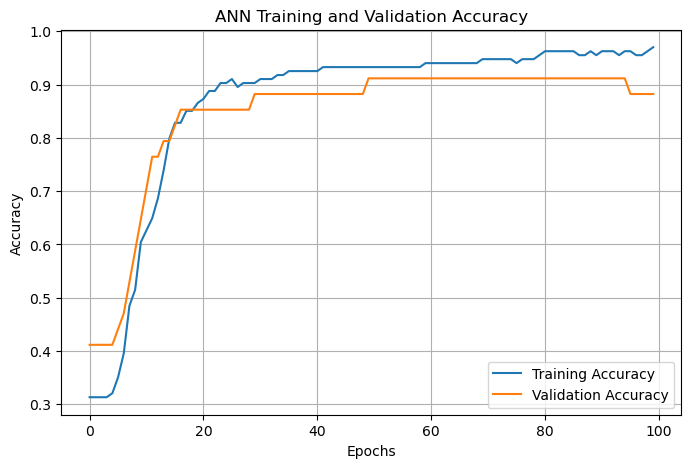

In [47]:
plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"],label="Training Accuracy")
plt.plot(history.history["val_accuracy"],label="Validation Accuracy")
plt.title("ANN Training and Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

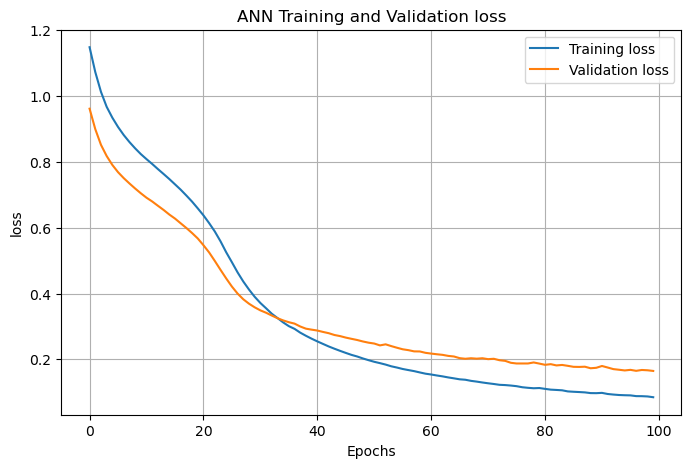

In [48]:
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"],label="Training loss")
plt.plot(history.history["val_loss"],label="Validation loss")
plt.title("ANN Training and Validation loss")
plt.xlabel("Epochs")
plt.ylabel("loss")
plt.legend()
plt.grid(True)
plt.show()

In [49]:
test_loss,test_accuracy = model.evaluate(X_test,y_test,verbose=1)
print("Test Loss:",test_loss)
print("Test Accuracy:", test_accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.3333 - loss: 46.3948
Test Loss: 46.394798278808594
Test Accuracy: 0.3333333432674408


In [51]:
y_prob = model.predict(X_test_scaled,verbose=1)
print(y_prob[:5])

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
[[9.9192083e-01 9.3422091e-04 7.1448982e-03]
 [5.8104455e-02 2.2521457e-05 9.4187295e-01]
 [4.7697052e-01 4.9029607e-01 3.2733388e-02]
 [5.5313011e-04 2.1883366e-08 9.9944681e-01]
 [1.6712091e-03 9.9829835e-01 3.0518560e-05]]


In [53]:
y_pred = np.argmax(y_prob,axis=1)
print("Predicted Encoded Classes:")
print(y_pred[:10])

Predicted Encoded Classes:
[0 2 1 2 1 2 1 1 1 1]


In [54]:
y_pred_original = y_pred + 1
y_test_original = y_test + 1
print("Predicted Classes:")
print(y_pred_original[:10])

Predicted Classes:
[1 3 2 3 2 3 2 2 2 2]


In [61]:
comparison = pd.DataFrame({
    "Actual Class": y_test_original.values,"Predicted Class": y_pred_original})
comparison.head(15)

,Actual Class,Predicted Class
0,1,1
1,3,3
2,2,2
3,3,3
4,2,2
5,3,3
6,2,2
7,1,2
8,2,2
9,2,2


In [62]:
accuracy = accuracy_score(y_test_original,y_pred_original)
print("Accuracy:",accuracy)

Accuracy: 0.8571428571428571


In [63]:
precision = precision_score(y_test_original,y_pred_original,average="weighted")
print("Precision:",precision)

Precision: 0.8823529411764707


In [64]:
recall = recall_score(y_test_original,y_pred_original,average="weighted")
print("recall:",recall)

recall: 0.8571428571428571


In [65]:
f1 = f1_score(y_test_original,y_pred_original,average="weighted")
print("f1 Score:",f1)

f1 Score: 0.8445747800586509


In [67]:
print(classification_report(y_test_original,y_pred_original))

              precision    recall  f1-score   support

           1       1.00      0.57      0.73        14
           2       0.82      1.00      0.90        14
           3       0.82      1.00      0.90        14

    accuracy                           0.86        42
   macro avg       0.88      0.86      0.84        42
weighted avg       0.88      0.86      0.84        42



In [68]:
cm = confusion_matrix(y_test_original,y_pred_original)
print(cm)

[[ 8  3  3]
 [ 0 14  0]
 [ 0  0 14]]
